<a href="https://colab.research.google.com/github/poudelef/Multi-Class-CNN-Model/blob/main/Multi_Class_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import data set


In [ ]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

#Unxip our data
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip",'r')
zip_ref.extractall()
zip_ref.close()

--2025-04-29 18:11:59--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.98.207, 142.251.107.207, 74.125.196.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  68.0MB/s    in 8.4s    

2025-04-29 18:12:07 (58.8 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
import os

# Walk through 10 clases of data
for dirpath, dirname, filenames in os.walk('10_food_classes_all_data'):
  print(f"There are {len(dirname)} directories and  {len(filenames)} images in '{dirpath}'.")

There are 2 directories and  0 images in '10_food_classes_all_data'.
There are 10 directories and  0 images in '10_food_classes_all_data/train'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/pizza'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and  750 images in '10_food_classes_all_data/train/chi

In [ ]:
# set uo the train and test directories
train_dir = '10_food_classes_all_data/train/'
test_dir = '10_food_classes_all_data/test/'

In [ ]:
# Let's get the class name
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


['273524.jpg']
(384, 512, 3)
589824


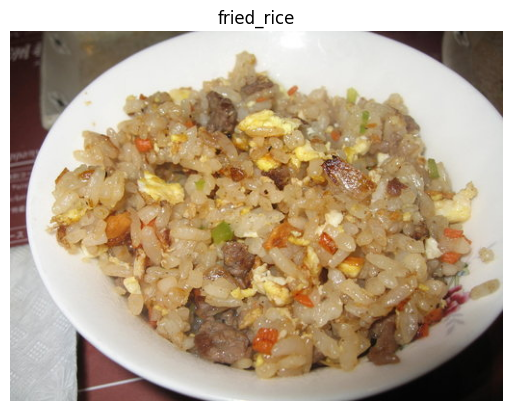

In [ ]:
# Visualize
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def view_random_images(target_dir, target_class):
  path = target_dir +'/' + target_class
  random_img = random.sample(os.listdir(path),1)
  print(random_img)
  img = mpimg.imread(path + "/" + random_img[0])
  # random_images is list so we index it to get a string value
  plt.imshow(img)
  plt.axis('off')
  plt.title(target_class)
  print(img.shape)
  print(img.size)

view_random_images(train_dir, random.choice(class_names))

## Preprocess the data

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)
train_dir = '10_food_classes_all_data/train/'
test_dir = '10_food_classes_all_data/test/'

train_datagen = ImageDataGenerator(
    rescale = 1/255.,
    rotation_range = 0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip = True,
    zoom_range=0.6)

test_datagen = ImageDataGenerator(rescale = 1/255.)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    seed = 42
)
test_data = train_datagen.flow_from_directory(
    test_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    seed = 42
)


Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Create a model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(2,3,input_shape= (224,224,3) ,activation ='relu'),
    Conv2D(4,3, activation ='relu'),
    MaxPool2D(),
    Conv2D(8,3, activation ='relu'),
    Conv2D(2,3, activation ='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10,activation ='softmax')
])

model.compile(loss='categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ['accuracy'])

history = model.fit(train_data,
                    epochs = 3,
                    steps_per_epoch = len(train_data),
                    validation_data = test_data,
                    validation_steps = len(test_data))

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 531ms/step - accuracy: 0.1080 - loss: 2.3004 - val_accuracy: 0.1580 - val_loss: 2.2472
Epoch 2/3
 99/235 ━━━━━━━━━━━━━━━━━━━━ 53s 390ms/step - accuracy: 0.1561 - loss: 2.2479

## Evaulate the model

In [ ]:
model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.3569 - loss: 1.8586


[1.8682326078414917, 0.35280001163482666]

<Axes: >

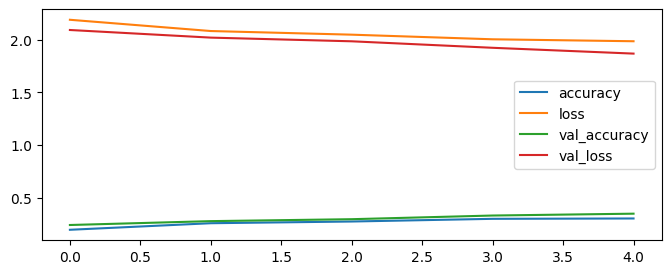

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,3))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)